# Swaption SABR Calibration and Volatility Cube Visualization

This notebook presents the theory, implementation, and visualization of the Interest Rate Swaption calibration engine using the Displaced (Shifted) SABR model.

---

## 1. Mathematical Theory

### 1.1 Interest Rate Swaptions Pricing
An interest rate swaption is an option to enter into an interest rate swap at a future date $T$ (expiry) with a fixed swap rate $K$ (strike) and swap maturity $T_m$ (tenor). 

For a payer swaption (option to pay fixed, receive floating), the payoff at expiry is:
$$ \text{Payoff} = A \max(S_T - K, 0) $$
where $S_T$ is the forward swap rate at expiry, and $A$ is the annuity factor (or PVBP - Present Value of a Basis Point) defined as:
$$ A = \sum_{i=1}^n \tau_i P(0, T_i) $$
with $\tau_i$ representing the accrual fraction and $P(0, T_i)$ the discount factor.

#### Normal (Bachelier) Model
Under the normal model, the swap rate is assumed to follow an arithmetic Brownian motion:
$$ dS_t = \sigma_N dW_t $$
The payer swaption price is given by the Bachelier formula (assuming discount factor/annuity $A=1$ for implied vol):
$$ V_{\text{payer}}(0) = (S_0 - K) N(d) + \sigma_N \sqrt{T} n(d) $$
where:
$$ d = \frac{S_0 - K}{\sigma_N \sqrt{T}} $$
and $N(\cdot)$, $n(\cdot)$ are the standard normal CDF and PDF.

#### Lognormal (Black) Model
Under the lognormal model, the swap rate is assumed to follow a geometric Brownian motion:
$$ dS_t = \sigma_L S_t dW_t $$
The payer swaption price is given by the Black formula:
$$ V_{\text{payer}}(0) = S_0 N(d_1) - K N(d_2) $$
where:
$$ d_1 = \frac{\ln(S_0 / K) + \frac{1}{2}\sigma_L^2 T}{\sigma_L \sqrt{T}}, \quad d_2 = d_1 - \sigma_L \sqrt{T} $$

---

### 1.2 Displaced (Shifted) SABR Dynamics
To handle low or negative interest rates, the standard SABR model is extended by introducing a displacement/shift parameter $\theta > 0$. The shifted swap rate $S_t + \theta$ is modeled as:
$$ d(S_t + \theta) = \alpha_t (S_t + \theta)^\beta dW_t^1 $$
$$ d\alpha_t = \nu \alpha_t dW_t^2 $$
$$ dW_t^1 dW_t^2 = \rho dt $$

where:
- $\alpha_t$ is the stochastic volatility (initialized at $\alpha = \alpha_0$).
- $\beta \in [0, 1]$ is the CEV exponent (typically fixed, e.g., $\beta = 0.5$ or $\beta = 0.7$).
- $\rho \in [-1, 1]$ is the correlation between the rate and its volatility.
- $\nu \geq 0$ is the vol-of-vol.
- $\theta$ is the shift (displacement), which ensures that $S_t + \theta > 0$ even if $S_t \leq 0$.

---

### 1.3 Hagan's Implied Volatility Approximations
Hagan et al. (2002) derived analytical approximations for the implied volatilities. Let $F = S_0 + \theta$ and $K_{\text{shift}} = K + \theta$.

#### Normal (Bachelier) Implied Volatility $\sigma_N(K)$
$$ \sigma_N(K) = \frac{\alpha (F - K_{\text{shift}})}{I_0} \cdot \left( \frac{z}{\chi(z)} \right) \cdot \left[ 1 + \left( -\frac{\beta(2-\beta)\alpha^2}{24(F K_{\text{shift}})^{1-\beta}} + \frac{\rho \beta \nu \alpha}{4(F K_{\text{shift}})^{(1-\beta)/2}} + \frac{2-3\rho^2}{24}\nu^2 \right) T \right] $$
where:
$$ I_0 = \begin{cases} \ln(F / K_{\text{shift}}) & \text{if } \beta = 1 \\ \frac{F^{1-\beta} - K_{\text{shift}}^{1-\beta}}{1-\beta} & \text{if } \beta < 1 \end{cases} $$
$$ z = \frac{\nu}{\alpha} I_0 $$
$$ \chi(z) = \ln \left( \frac{\sqrt{1 - 2\rho z + z^2} + z - \rho}{1 - \rho} \right) $$

For the At-The-Money (ATM) case ($F = K_{\text{shift}}$):
$$ \sigma_{N,\text{ATM}} = \alpha F^\beta \left[ 1 + \left( -\frac{\beta(2-\beta)\alpha^2}{24 F^{2-2\beta}} + \frac{\rho \beta \nu \alpha}{4 F^{1-\beta}} + \frac{2-3\rho^2}{24}\nu^2 \right) T \right] $$

---

### 1.4 Cubic ATM Reduction (2D Optimization)
In the 3D calibration, we optimize over $(\alpha, \rho, \nu)$ to fit the volatility smile. However, since the ATM volatility $\sigma_{\text{ATM}}$ is known with high precision, we can use the ATM relation to solve for $\alpha$ in terms of $\rho$ and $\nu$. 

Letting $A = \alpha F_s^{-\beta}$ (for normal vol) or $A = \alpha F_s^{\beta-1}$ (for lognormal vol), the ATM volatility formula can be rewritten as a cubic equation in $A$:
$$ C_3 A^3 + C_2 A^2 + C_1 A + C_0 = 0 $$
where:
- For normal volatility:
  $$ C_3 = -\frac{\beta(2-\beta)T}{24 F_s^2} $$
  $$ C_2 = \frac{\rho \beta \nu T}{4 F_s} $$
  $$ C_1 = 1 + \frac{2-3\rho^2}{24}\nu^2 T $$
  $$ C_0 = -\sigma_{\text{ATM}} $$

Solving this cubic equation for $A$ analytically or via Brent's method yields $\alpha$. This reduces the search space of the optimizer from 3D to 2D $(\rho, \nu)$, ensuring faster convergence and preventing parameter destabilization.

---

### 1.5 Swaption Volatility Cube and Bilinear Interpolation
A swaption volatility cube is structured over three axes:
1. **Option Expiry** ($T_{\text{exp}}$)
2. **Swap Tenor** ($T_{\text{tenor}}$)
3. **Relative Strike** or Moneyness ($K - S_0$, in bps)

At each grid node $(T_{\text{exp}}, T_{\text{tenor}})$, the SABR model is calibrated. For non-grid expiries and tenors, the calibrated SABR parameters $(\alpha, \rho, \nu)$ are interpolated using bilinear interpolation:
$$ P(x, y) = w_{11} P_{11} + w_{21} P_{21} + w_{12} P_{12} + w_{22} P_{22} $$
with flat extrapolation outside the grid bounds.


In [1]:
import os
import sys
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import time

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Inject src path to import local modules
sys.path.insert(0, os.path.abspath("../src"))

from pricing.bachelier import (
    bachelier_price,
    black_price,
    shifted_black_price,
    bachelier_implied_vol,
    black_implied_vol
)
from market.rates_data import (
    load_sofr_swap_rates,
    get_synthetic_forward_rates,
    load_swaption_vol_cube
)
from pricing.sabr_rates import (
    displaced_sabr_vol,
    calibrate_sabr_node,
    SwaptionVolCube,
    bilinear_interpolate
)

print("Imports successful!")


Imports successful!


In [2]:
# Load rates and vol cube data
sofr_swap_rates = load_sofr_swap_rates()
expiries, tenors, relative_strikes, market_vols = load_swaption_vol_cube()
forward_rates = get_synthetic_forward_rates(expiries, tenors)

print("Loaded SOFR Swap Rates (sample):")
for tenor, rate in list(sofr_swap_rates.items())[:5]:
    print(f"  Tenor {tenor:>4.1f}Y: {rate*100:6.3f}%")

print("\nSwaption Volatility Cube Grid:")
print(f"  Option Expiries (T_exp): {expiries} years (count: {len(expiries)})")
print(f"  Swap Tenors (T_tenor)  : {tenors} years (count: {len(tenors)})")
print(f"  Relative Strikes (bps) : {relative_strikes} bps (count: {len(relative_strikes)})")
print(f"  Market Vols Shape      : {market_vols.shape} (Expiry x Tenor x Strike)")

# Display a slice at the ATM strike (relative_strikes == 0)
atm_idx = np.argmin(np.abs(relative_strikes))
print(f"\nMarket ATM Volatilities (in bps of normal vol, at rel_strike = 0):")
print("Tenor ->   " + "   ".join([f"{t:>5.1f}Y" for t in tenors]))
for i, exp in enumerate(expiries):
    row_str = f"Expiry {exp:>2.1f}Y: "
    vols_row = market_vols[i, :, atm_idx] * 1e4 # convert to bps
    row_str += " ".join([f"{v:7.2f}" for v in vols_row])
    print(row_str)


Loaded SOFR Swap Rates (sample):
  Tenor  1.0Y:  3.500%
  Tenor  2.0Y:  3.300%
  Tenor  3.0Y:  3.150%
  Tenor  4.0Y:  3.050%
  Tenor  5.0Y:  3.000%

Swaption Volatility Cube Grid:
  Option Expiries (T_exp): [ 1.  2.  5. 10.] years (count: 4)
  Swap Tenors (T_tenor)  : [ 1.  2.  5. 10. 30.] years (count: 5)
  Relative Strikes (bps) : [-200. -100.  -50.    0.   50.  100.  200.] bps (count: 7)
  Market Vols Shape      : (4, 5, 7) (Expiry x Tenor x Strike)

Market ATM Volatilities (in bps of normal vol, at rel_strike = 0):
Tenor ->     1.0Y     2.0Y     5.0Y    10.0Y    30.0Y
Expiry 1.0Y:   78.70   78.40   77.50   76.00   70.00
Expiry 2.0Y:   77.70   77.40   76.50   75.00   69.00
Expiry 5.0Y:   74.70   74.40   73.50   72.00   66.00
Expiry 10.0Y:   69.70   69.40   68.50   67.00   61.00


In [3]:
# Custom 3D SABR Node Calibration for comparison
def calibrate_sabr_node_3d(F, strikes, market_vols, T, beta, shift, vol_type='normal'):
    F = float(F)
    T = float(T)
    beta = float(beta)
    shift = float(shift)
    
    strikes = np.asarray(strikes, dtype=float)
    market_vols = np.asarray(market_vols, dtype=float)
    
    atm_idx = np.argmin(np.abs(strikes - F))
    atm_vol = market_vols[atm_idx]
    
    F_s = F + shift
    if vol_type.lower() == 'normal':
        alpha_init = atm_vol / (F_s ** beta)
    else:
        alpha_init = atm_vol * (F_s ** (1.0 - beta))
        
    alpha_init = np.clip(alpha_init, 1e-4, 5.0)
    rho_init = 0.0
    nu_init = 0.3
    
    # 3D parameter optimization: [alpha, rho, nu]
    x0 = [alpha_init, rho_init, nu_init]
    bounds = ([1e-5, -0.999, 1e-5], [10.0, 0.999, 5.0])
    
    def residuals_3d(params):
        alpha_val, rho_val, nu_val = params
        model_vols = displaced_sabr_vol(F, strikes, T, alpha_val, beta, rho_val, nu_val, shift, vol_type=vol_type)
        res = model_vols - market_vols
        res = np.where(np.isnan(res), 1e6, res)
        return res
        
    res = opt.least_squares(residuals_3d, x0, bounds=bounds, method='trf')
    return res.x

def calibrate_cube_3d(cube, market_cube_vols, forward_rates, beta=0.5, shift=0.01, vol_type='normal'):
    num_exp = len(cube.expiries)
    num_ten = len(cube.tenors)
    
    alpha = np.zeros((num_exp, num_ten))
    rho = np.zeros((num_exp, num_ten))
    nu = np.zeros((num_exp, num_ten))
    
    for i, T in enumerate(cube.expiries):
        for j, tenor in enumerate(cube.tenors):
            F = forward_rates[i, j]
            strikes = F + cube.relative_strikes * 1e-4
            market_vols_node = market_cube_vols[i, j, :]
            
            b_node = beta[i, j] if not np.isscalar(beta) else beta
            sh_node = shift[i, j] if not np.isscalar(shift) else shift
            
            a, r, n = calibrate_sabr_node_3d(F, strikes, market_vols_node, T, b_node, sh_node, vol_type)
            alpha[i, j] = a
            rho[i, j] = r
            nu[i, j] = n
            
    return alpha, rho, nu

# ----------------- Perform Calibration Benchmarking -----------------

cube = SwaptionVolCube(expiries, tenors, relative_strikes)

# 1. Sequential 3D Calibration
print("Running Sequential 3D Calibration...")
start_time = time.time()
alpha_3d, rho_3d, nu_3d = calibrate_cube_3d(cube, market_vols, forward_rates, beta=0.5, shift=0.01, vol_type='normal')
time_3d = time.time() - start_time
print(f"Sequential 3D Calibration completed in {time_3d:.4f} seconds.\n")

# 2. Sequential 2D (ATM-reduced) Calibration
print("Running Sequential 2D (ATM-reduced) Calibration...")
start_time = time.time()
cube.calibrate(market_vols, forward_rates, beta=0.5, shift=0.01, vol_type='normal', parallel=False)
time_2d_seq = time.time() - start_time
print(f"Sequential 2D Calibration completed in {time_2d_seq:.4f} seconds.\n")

# 3. Parallel 2D Calibration
print("Running Parallel 2D Calibration...")
start_time = time.time()
cube.calibrate(market_vols, forward_rates, beta=0.5, shift=0.01, vol_type='normal', parallel=True)
time_2d_par = time.time() - start_time
print(f"Parallel 2D Calibration completed in {time_2d_par:.4f} seconds.\n")

# Summarize Speedups
print("=" * 60)
print("CALIBRATION TIME COMPARISON")
print("=" * 60)
print(f"Sequential 3D Calibration : {time_3d:8.4f}s  (baseline)")
print(f"Sequential 2D ATM-reduced : {time_2d_seq:8.4f}s  (Speedup: {time_3d / time_2d_seq:.2f}x)")
print(f"Parallel 2D ATM-reduced   : {time_2d_par:8.4f}s  (Speedup: {time_3d / time_2d_par:.2f}x)")
print("=" * 60)


Running Sequential 3D Calibration...
Sequential 3D Calibration completed in 0.1080 seconds.

Running Sequential 2D (ATM-reduced) Calibration...


Sequential 2D Calibration completed in 0.1254 seconds.

Running Parallel 2D Calibration...


Parallel 2D Calibration completed in 0.1401 seconds.

CALIBRATION TIME COMPARISON
Sequential 3D Calibration :   0.1080s  (baseline)
Sequential 2D ATM-reduced :   0.1254s  (Speedup: 0.86x)
Parallel 2D ATM-reduced   :   0.1401s  (Speedup: 0.77x)


In [4]:
# Interpolate parameters at a non-grid point
T_exp_target = 3.5
T_tenor_target = 7.5

alpha_interp, beta_interp, rho_interp, nu_interp, shift_interp = cube.interpolate_params(T_exp_target, T_tenor_target)

print(f"Interpolated SABR parameters at Expiry = {T_exp_target}Y, Tenor = {T_tenor_target}Y:")
print(f"  alpha : {alpha_interp:8.6f}")
print(f"  beta  : {beta_interp:8.6f}")
print(f"  rho   : {rho_interp:8.6f}")
print(f"  nu    : {nu_interp:8.6f}")
print(f"  shift : {shift_interp:8.6f}")

# Also verify that the interpolated smile can be computed and is smooth
F_target = bilinear_interpolate(T_exp_target, T_tenor_target, expiries, tenors, forward_rates)
strikes_target = F_target + np.linspace(-150, 150, 50) * 1e-4
smile_vols_target = cube.get_smile(T_exp_target, T_tenor_target, strikes_target, vol_type='normal')

print(f"\nForward rate at target node: {F_target*100:.4f}%")
print(f"Successfully generated {len(smile_vols_target)} vols for the smile (ATM vol: {smile_vols_target[len(smile_vols_target)//2]*1e4:.2f} bps).")


Interpolated SABR parameters at Expiry = 3.5Y, Tenor = 7.5Y:
  alpha : 0.033988
  beta  : 0.500000
  rho   : -0.530213
  nu    : 0.409446
  shift : 0.010000

Forward rate at target node: 3.6750%
Successfully generated 50 vols for the smile (ATM vol: 74.06 bps).


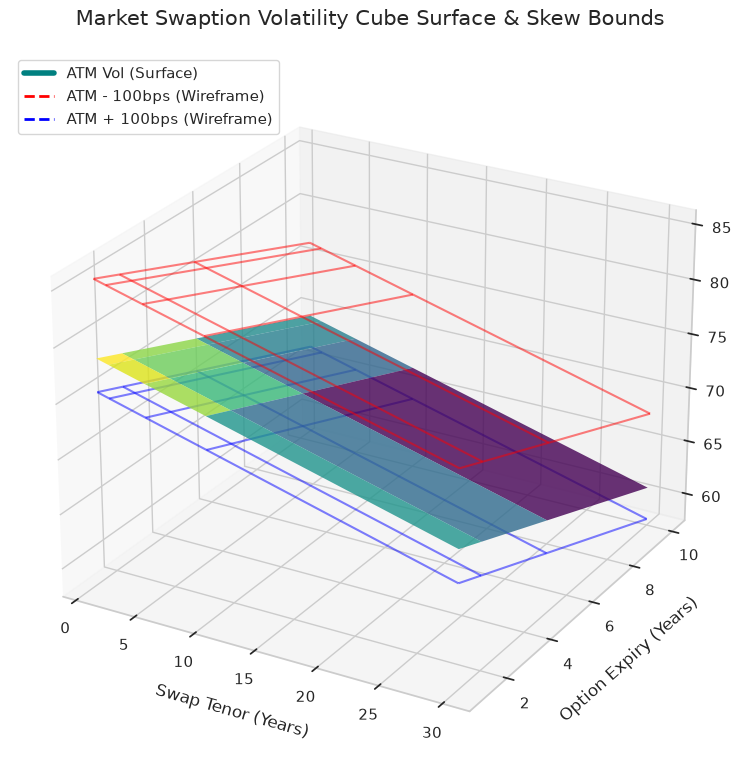

In [5]:
# 3D surface plot of the market swaption volatility cube at ATM and strikes
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the grid
T_mesh, E_mesh = np.meshgrid(tenors, expiries)

# Get ATM vol (rel_strike = 0) in bps
atm_idx = np.argmin(np.abs(relative_strikes))
Z_atm = market_vols[:, :, atm_idx] * 1e4

# Plot ATM surface
surf_atm = ax.plot_surface(T_mesh, E_mesh, Z_atm, cmap='viridis', alpha=0.8, edgecolor='none', label='ATM Vol')

# Also plot the -100 bps and +100 bps surfaces as wireframes to visualize the cube/smile dimension
idx_down = np.argmin(np.abs(relative_strikes - (-100.0)))
idx_up = np.argmin(np.abs(relative_strikes - 100.0))

Z_down = market_vols[:, :, idx_down] * 1e4
Z_up = market_vols[:, :, idx_up] * 1e4

# Plot wireframes for skew boundaries
wire_down = ax.plot_wireframe(T_mesh, E_mesh, Z_down, color='red', alpha=0.5, label='ATM - 100bps')
wire_up = ax.plot_wireframe(T_mesh, E_mesh, Z_up, color='blue', alpha=0.5, label='ATM + 100bps')

# Add labels and titles
ax.set_xlabel('Swap Tenor (Years)', labelpad=10)
ax.set_ylabel('Option Expiry (Years)', labelpad=10)
ax.set_zlabel('Normal Volatility (bps)', labelpad=10)
ax.set_title('Market Swaption Volatility Cube Surface & Skew Bounds', fontsize=15, pad=20)

# Add colorbar (need to pass a mappable, so use a dummy or just show the legend)
# Since plot_surface doesn't support legend easily, we will add manually
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='teal', lw=4, label='ATM Vol (Surface)'),
    Line2D([0], [0], color='red', lw=2, linestyle='--', label='ATM - 100bps (Wireframe)'),
    Line2D([0], [0], color='blue', lw=2, linestyle='--', label='ATM + 100bps (Wireframe)')
]
ax.legend(handles=legend_elements, loc='upper left')

ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()


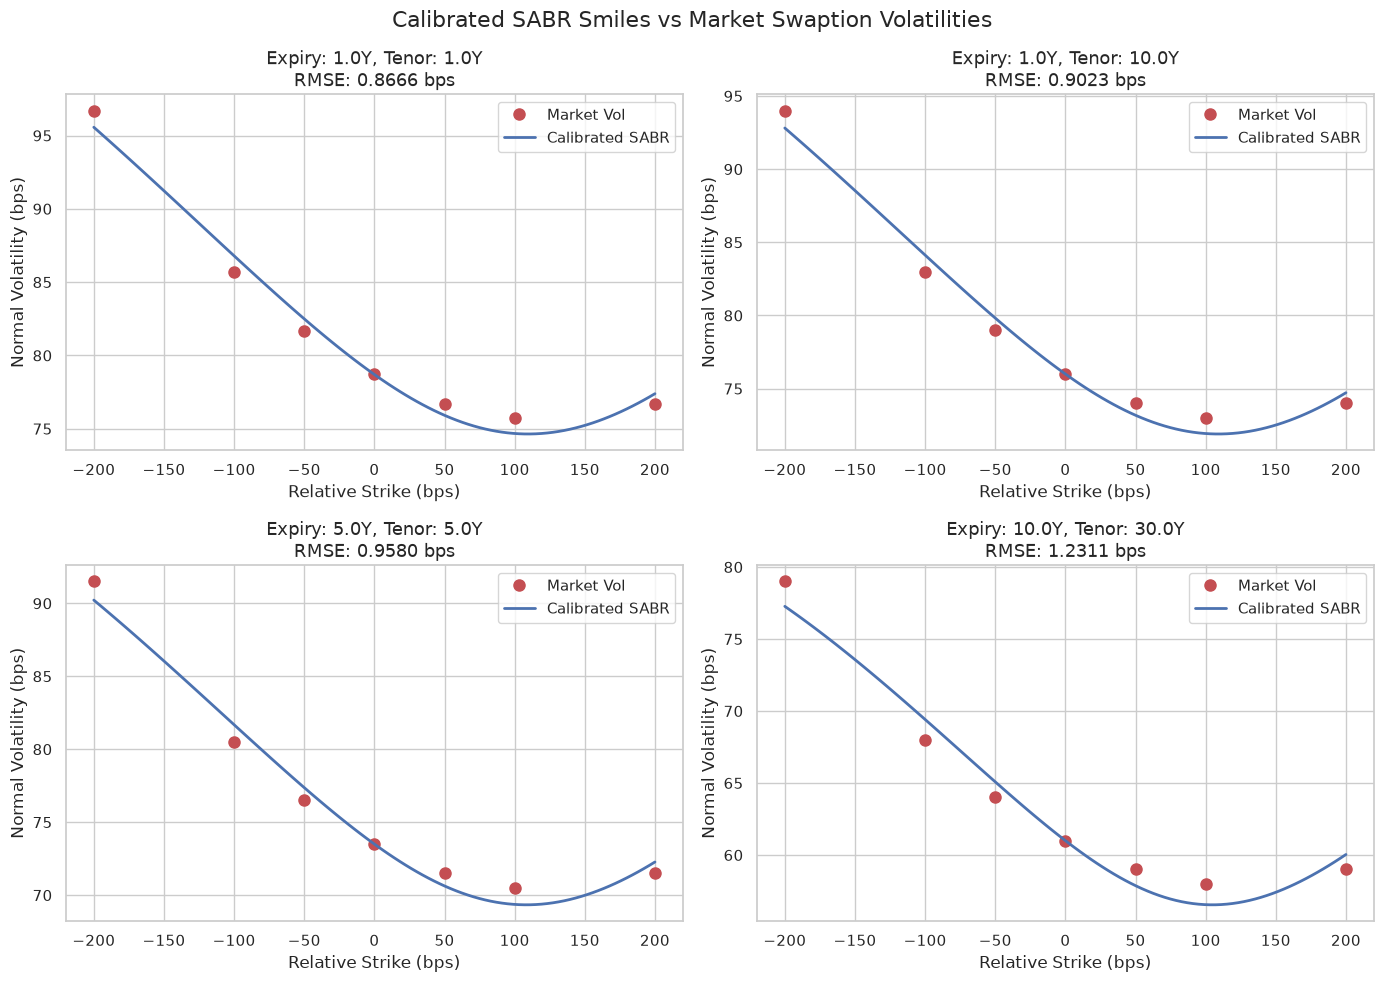

In [6]:
# Selected grid nodes to show the fit quality
selected_nodes = [
    (0, 0),   # Expiry = 1Y, Tenor = 1Y
    (0, 3),   # Expiry = 1Y, Tenor = 10Y
    (2, 2),   # Expiry = 5Y, Tenor = 5Y
    (3, 4)    # Expiry = 10Y, Tenor = 30Y
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (i_exp, j_ten) in enumerate(selected_nodes):
    exp = expiries[i_exp]
    ten = tenors[j_ten]
    F = forward_rates[i_exp, j_ten]
    
    # Retrieve calibrated parameters
    alpha = cube.alpha[i_exp, j_ten]
    beta = cube.beta[i_exp, j_ten]
    rho = cube.rho[i_exp, j_ten]
    nu = cube.nu[i_exp, j_ten]
    shift = cube.shift[i_exp, j_ten]
    
    # Market data points
    mkt_vols = market_vols[i_exp, j_ten, :]
    strikes_mkt = F + relative_strikes * 1e-4
    
    # Model smile (continuous line)
    rel_strikes_fine = np.linspace(relative_strikes[0], relative_strikes[-1], 100)
    strikes_fine = F + rel_strikes_fine * 1e-4
    model_vols_fine = displaced_sabr_vol(F, strikes_fine, exp, alpha, beta, rho, nu, shift, vol_type='normal')
    
    # Model vols at market strikes for error computation
    model_vols_mkt = displaced_sabr_vol(F, strikes_mkt, exp, alpha, beta, rho, nu, shift, vol_type='normal')
    rmse_bps = np.sqrt(np.mean((model_vols_mkt - mkt_vols)**2)) * 1e4
    
    ax = axes[idx]
    ax.plot(relative_strikes, mkt_vols * 1e4, 'ro', label='Market Vol', markersize=8)
    ax.plot(rel_strikes_fine, model_vols_fine * 1e4, 'b-', label='Calibrated SABR', linewidth=2)
    
    ax.set_title(f"Expiry: {exp}Y, Tenor: {ten}Y\nRMSE: {rmse_bps:.4f} bps", fontsize=13)
    ax.set_xlabel("Relative Strike (bps)")
    ax.set_ylabel("Normal Volatility (bps)")
    ax.legend()
    
plt.suptitle("Calibrated SABR Smiles vs Market Swaption Volatilities", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


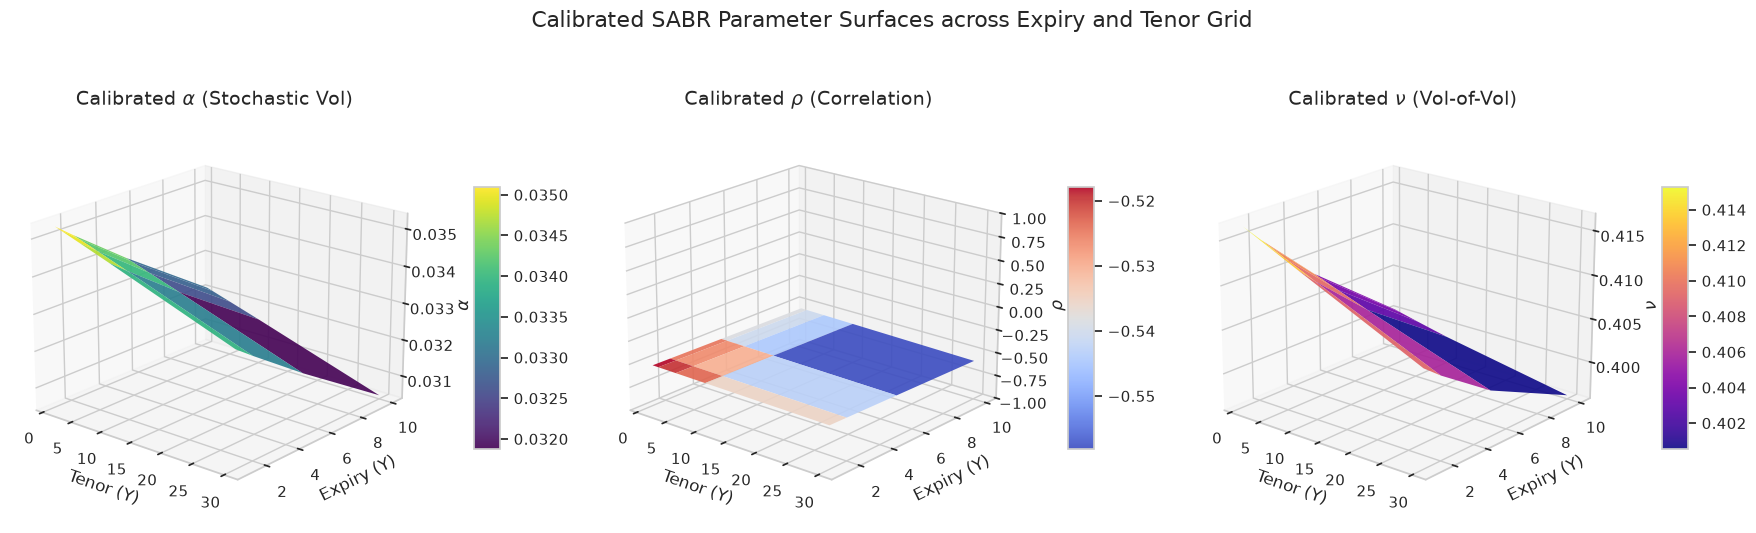

In [7]:
# Plot calibrated SABR parameter surfaces to verify smoothness
fig = plt.figure(figsize=(18, 6))

# Meshgrid for plotting
T_mesh, E_mesh = np.meshgrid(tenors, expiries)

# Subplot 1: Alpha
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(T_mesh, E_mesh, cube.alpha, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_title(r'Calibrated $\alpha$ (Stochastic Vol)', fontsize=14)
ax1.set_xlabel('Tenor (Y)')
ax1.set_ylabel('Expiry (Y)')
ax1.set_zlabel(r'$\alpha$')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, pad=0.1)

# Subplot 2: Rho
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(T_mesh, E_mesh, cube.rho, cmap='coolwarm', edgecolor='none', alpha=0.9)
ax2.set_title(r'Calibrated $\rho$ (Correlation)', fontsize=14)
ax2.set_xlabel('Tenor (Y)')
ax2.set_ylabel('Expiry (Y)')
ax2.set_zlabel(r'$\rho$')
# Set bounds for rho
ax2.set_zlim(-1.0, 1.0)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, pad=0.1)

# Subplot 3: Nu
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(T_mesh, E_mesh, cube.nu, cmap='plasma', edgecolor='none', alpha=0.9)
ax3.set_title(r'Calibrated $\nu$ (Vol-of-Vol)', fontsize=14)
ax3.set_xlabel('Tenor (Y)')
ax3.set_ylabel('Expiry (Y)')
ax3.set_zlabel(r'$\nu$')
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10, pad=0.1)

# Rotate for better view angles
for ax in [ax1, ax2, ax3]:
    ax.view_init(elev=20, azim=-50)

plt.suptitle("Calibrated SABR Parameter Surfaces across Expiry and Tenor Grid", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()
